In [ ]:
import os
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 90)
print(" INSPEKSI STRUKTUR KOLOM SELURUH FILE CSV EEG")
print("=" * 90)

# Pastikan path ini sesuai dengan variabel project_root Anda sebelumnya
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '../../../'))
cleaned_csv_path = os.path.join(project_root, 'dataset/cleaned_transcript_mapping.csv')
raw_data_path = os.path.join(project_root, 'dataset/raw')

# 1. Load Mapping Data
df_map = pd.read_csv(cleaned_csv_path)
subject_info = df_map.groupby('subject').first()[['gender']].reset_index()
subject_gender_map = dict(zip(subject_info['subject'], subject_info['gender']))

subject_ids = defaultdict(list)
for idx, row in df_map.iterrows():
    subject_ids[row['subject']].append(row['id'])

# 2. Struktur Data untuk Tracking Kolom
# Menyimpan kombinasi kolom unik sebagai tuple, dan menghitung berapa file yang memilikinya
column_structures = defaultdict(list)
all_unique_columns = set()
total_files_checked = 0
files_not_found = []

print("Memindai seluruh file CSV (Mengekstrak Header)...\n")

# 3. Iterasi ke setiap subjek dan ID
for subject in sorted(subject_ids.keys()):
    gender = subject_gender_map[subject]
    csv_folder = os.path.join(raw_data_path, gender, subject, 'csv')
    
    if not os.path.isdir(csv_folder):
        continue
        
    available_csvs = [f for f in os.listdir(csv_folder) if f.endswith('.bp.csv')]
    
    for id_val in subject_ids[subject]:
        # Cari file yang sesuai dengan id_val_ prefix dan .bp.csv suffix
        matching_files = [f for f in available_csvs if f.startswith(id_val + '_')]
        
        if matching_files:
            file_name = matching_files[0]
            file_path = os.path.join(csv_folder, file_name)
            
            try:
                # BACA HEADER SAJA: skiprows=1 (melewati baris metadata), nrows=0 (hanya ambil nama kolom)
                # Ini membuat proses ribuan kali lebih cepat daripada membaca seluruh baris data
                df_header = pd.read_csv(file_path, skiprows=1, nrows=0)
                columns = tuple(df_header.columns.tolist()) # Ubah ke tuple agar bisa jadi key dictionary
                
                # Simpan strukturnya
                column_structures[columns].append(f"{subject}/{file_name}")
                all_unique_columns.update(columns)
                total_files_checked += 1
                
            except Exception as e:
                print(f"Error membaca file {file_name}: {e}")
        else:
            files_not_found.append(f"{id_val} (Subject: {subject})")

# ==========================================
# 4. REPORTING HASIL
# ==========================================
print("=" * 90)
print(" HASIL INSPEKSI KOLOM")
print("=" * 90)
print(f"Total file CSV yang berhasil dicek : {total_files_checked} file")
if files_not_found:
    print(f"Total file yang tidak ditemukan    : {len(files_not_found)} file")

print(f"\nTotal kolom unik yang ditemukan di seluruh dataset: {len(all_unique_columns)} kolom")

print("\n" + "=" * 90)
print(" KONSISTENSI STRUKTUR KOLOM")
print("=" * 90)

num_variations = len(column_structures)
if num_variations == 1:
    print("✅ STATUS: SANGAT KONSISTEN!")
    print("Semua file CSV memiliki jumlah dan susunan kolom yang SAMA PERSIS.")
    
    # Ambil satu-satunya struktur kolom yang ada
    the_columns = list(column_structures.keys())[0]
    print(f"\nJumlah Kolom per File: {len(the_columns)}")
    print("\n[ DAFTAR LENGKAP KOLOM ]:")
    
    # Kelompokkan kolom agar mudah dibaca (opsional, berdasarkan prefix standar Emotiv)
    eeg_cols = [c for c in the_columns if 'EEG' in c or c in ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']]
    cq_cols = [c for c in the_columns if 'CQ' in c]
    mot_cols = [c for c in the_columns if 'MOT' in c or 'Q0' in c or 'ACC' in c]
    other_cols = [c for c in the_columns if c not in eeg_cols and c not in cq_cols and c not in mot_cols]
    
    if eeg_cols: print(f"-> Sensor Gelombang Otak ({len(eeg_cols)}): {eeg_cols}")
    if cq_cols: print(f"-> Kualitas Sinyal / Contact Quality ({len(cq_cols)}): {cq_cols}")
    if mot_cols: print(f"-> Sensor Gerak / Motion ({len(mot_cols)}): {mot_cols}")
    print(f"-> Kolom Lainnya (Waktu, Marker, dll) ({len(other_cols)}): {other_cols}")

else:
    print("❌ STATUS: DITEMUKAN PERBEDAAN STRUKTUR KOLOM!")
    print(f"Terdapat {num_variations} variasi struktur kolom yang berbeda di dalam dataset Anda.\n")
    
    # Urutkan dari struktur yang paling banyak dimiliki file
    sorted_structures = sorted(column_structures.items(), key=lambda x: len(x[1]), reverse=True)
    
    major_columns = set(sorted_structures[0][0])
    print(f"Variasi 1 (Mayoritas): Dimiliki oleh {len(sorted_structures[0][1])} file.")
    print(f"Jumlah kolom: {len(major_columns)} kolom.")
    
    for i, (cols_tuple, file_list) in enumerate(sorted_structures[1:], start=2):
        minor_columns = set(cols_tuple)
        print(f"\n--------------------------------------------------")
        print(f"Variasi {i} (Minoritas): Dimiliki oleh {len(file_list)} file.")
        print(f"Jumlah kolom: {len(minor_columns)} kolom.")
        
        # Cari perbedaannya dengan mayoritas
        missing_in_minor = major_columns - minor_columns
        extra_in_minor = minor_columns - major_columns
        
        if missing_in_minor:
            print(f"[-] Kolom yang HILANG di variasi ini: {missing_in_minor}")
        if extra_in_minor:
            print(f"[+] Kolom TAMBAHAN di variasi ini: {extra_in_minor}")
            
        print(f"Contoh file dengan variasi ini: {file_list[0]}")

print("\n" + "=" * 90)

 INSPEKSI STRUKTUR KOLOM SELURUH FILE CSV EEG
Memindai seluruh file CSV (Mengekstrak Header)...

 HASIL INSPEKSI KOLOM
Total file CSV yang berhasil dicek : 1050 file

Total kolom unik yang ditemukan di seluruh dataset: 183 kolom

 KONSISTENSI STRUKTUR KOLOM
❌ STATUS: DITEMUKAN PERBEDAAN STRUKTUR KOLOM!
Terdapat 2 variasi struktur kolom yang berbeda di dalam dataset Anda.

Variasi 1 (Mayoritas): Dimiliki oleh 813 file.
Jumlah kolom: 183 kolom.

--------------------------------------------------
Variasi 2 (Minoritas): Dimiliki oleh 237 file.
Jumlah kolom: 182 kolom.
[-] Kolom yang HILANG di variasi ini: {'OriginalTimestamp'}
Contoh file dengan variasi ini: DAM/32_DAM_EPOCX_728072_2026.02.27T12.55.58+07.00.md.mc.pm.fe.bp.csv



In [19]:
print("=" * 70)
print(" DAFTAR SELURUH NAMA KOLOM PADA FILE CSV EEG (SAMPEL)")
print("=" * 70)

# Sesuaikan dengan path root direktori Anda
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '../../../'))
raw_data_path = os.path.join(project_root, 'dataset/raw')

# Mencari SATU file .bp.csv pertama yang bisa ditemukan sebagai sampel
sample_file_path = None

# Menyusuri direktori untuk mencari file target
for root, dirs, files in os.walk(raw_data_path):
    for file in files:
        if file.endswith('.bp.csv'):
            sample_file_path = os.path.join(root, file)
            break # Langsung berhenti setelah menemukan 1 file
    if sample_file_path:
        break

if sample_file_path:
    # Ambil nama file untuk informasi
    file_name_only = os.path.basename(sample_file_path)
    print(f"File Sampel : {file_name_only}\n")
    
    try:
        # BACA HEADER SAJA: skiprows=1 (melewati metadata), nrows=0 (ambil nama kolom)
        df_sample = pd.read_csv(sample_file_path, skiprows=1, nrows=0)
        all_columns = df_sample.columns.tolist()
        
        print(f"Total Kolom : {len(all_columns)} Kolom\n")
        print("-" * 30)
        
        # Menampilkan kolom secara vertikal beserta nomor urutnya
        for i, col in enumerate(all_columns, start=1):
            # Menggunakan format string agar nomor urut rata kanan
            print(f"{col},")
            
    except Exception as e:
        print(f"❌ Terjadi kesalahan saat membaca file: {e}")
else:
    print("❌ Tidak ditemukan file .bp.csv di dalam direktori dataset/raw.")

 DAFTAR SELURUH NAMA KOLOM PADA FILE CSV EEG (SAMPEL)
File Sampel : 89_MAR_EPOCX_729429_2026.02.28T14.09.33+07.00.md.mc.pm.fe.bp.csv

Total Kolom : 183 Kolom

------------------------------
Timestamp,
OriginalTimestamp,
EEG.Counter,
EEG.Interpolated,
EEG.AF3,
EEG.F7,
EEG.F3,
EEG.FC5,
EEG.T7,
EEG.P7,
EEG.O1,
EEG.O2,
EEG.P8,
EEG.T8,
EEG.FC6,
EEG.F4,
EEG.F8,
EEG.AF4,
EEG.RawCq,
EEG.Battery,
EEG.BatteryPercent,
MarkerIndex,
MarkerType,
MarkerValueInt,
EEG.MarkerHardware,
CQ.AF3,
CQ.F7,
CQ.F3,
CQ.FC5,
CQ.T7,
CQ.P7,
CQ.O1,
CQ.O2,
CQ.P8,
CQ.T8,
CQ.FC6,
CQ.F4,
CQ.F8,
CQ.AF4,
CQ.Overall,
EQ.SampleRateQuality,
EQ.OVERALL,
EQ.AF3,
EQ.F7,
EQ.F3,
EQ.FC5,
EQ.T7,
EQ.P7,
EQ.O1,
EQ.O2,
EQ.P8,
EQ.T8,
EQ.FC6,
EQ.F4,
EQ.F8,
EQ.AF4,
MOT.CounterMems,
MOT.InterpolatedMems,
MOT.Q0,
MOT.Q1,
MOT.Q2,
MOT.Q3,
MOT.AccX,
MOT.AccY,
MOT.AccZ,
MOT.MagX,
MOT.MagY,
MOT.MagZ,
MC.Action,
MC.ActionPower,
MC.IsActive,
PM.Attention.IsActive,
PM.Attention.Scaled,
PM.Attention.Raw,
PM.Attention.Min,
PM.Attention.Max,
PM.Engage

 ANALISIS MISSING VALUES (NULL/NAN) PER KOLOM
Memproses seluruh file CSV untuk menghitung Null Values...


/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16268/417095933.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


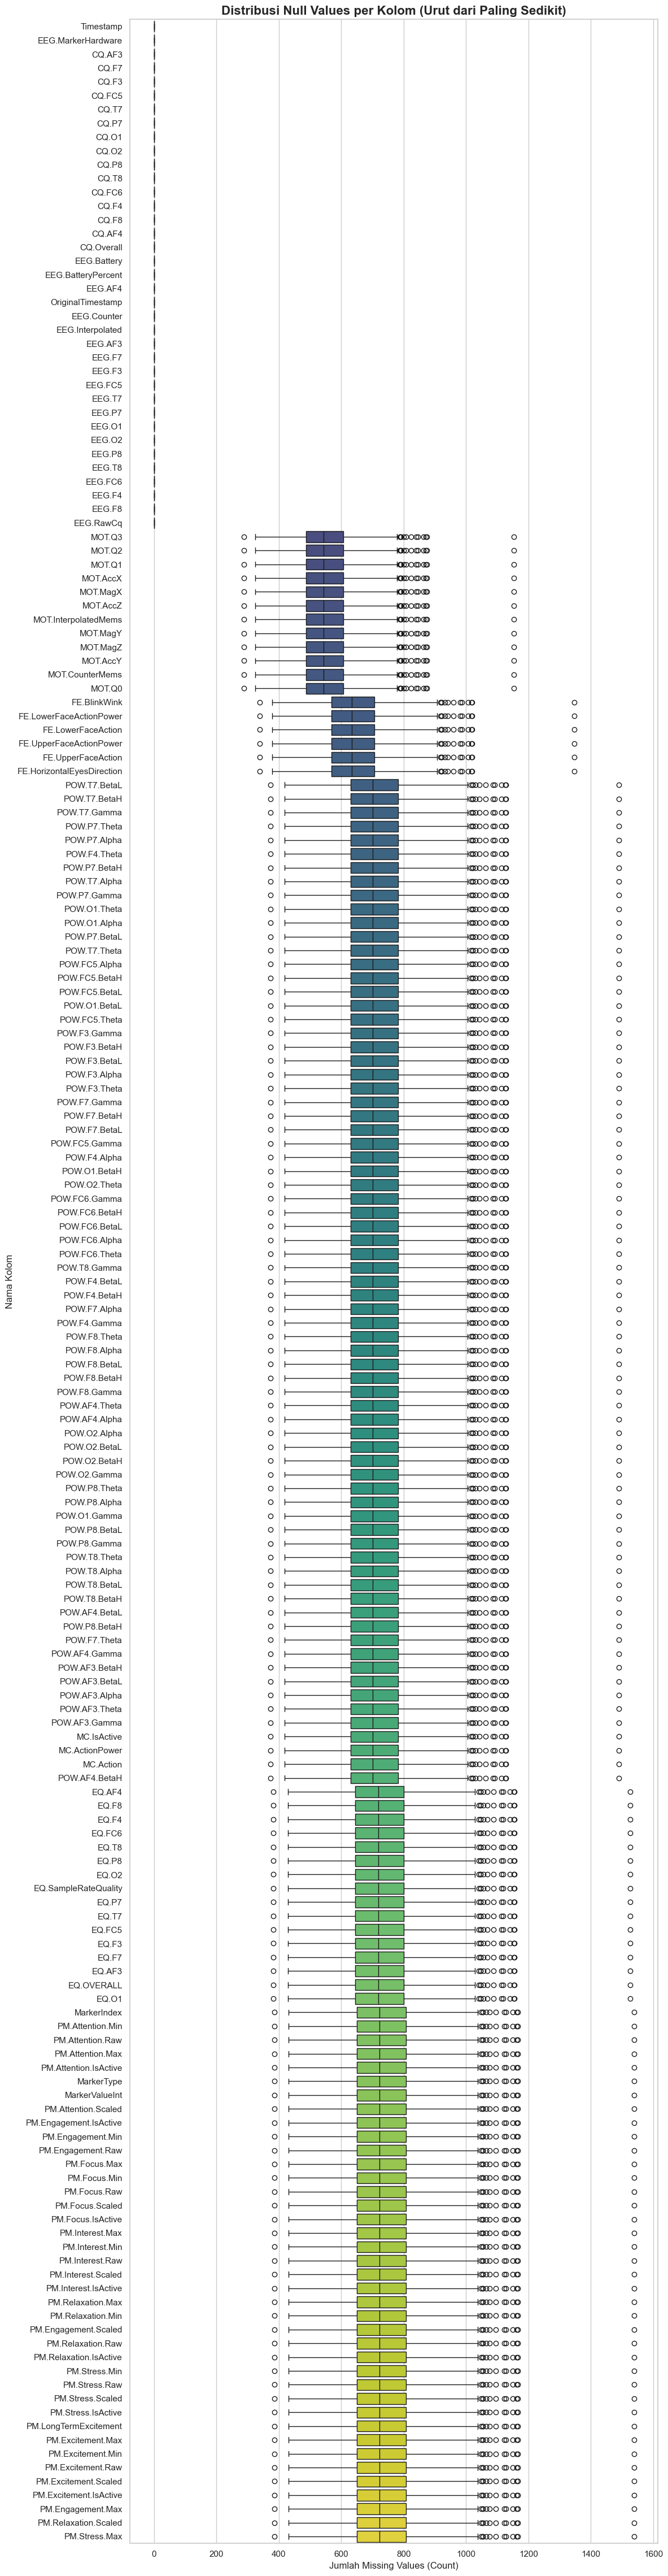


 URUTAN KOLOM BERDASARKAN JUMLAH NULL VALUES TERSEDIKIT
No   | Nama Kolom                | Total Null (All Files)
------------------------------------------------------------
1    | Timestamp                 | 0                   
2    | EEG.MarkerHardware        | 0                   
3    | CQ.AF3                    | 0                   
4    | CQ.F7                     | 0                   
5    | CQ.F3                     | 0                   
6    | CQ.FC5                    | 0                   
7    | CQ.T7                     | 0                   
8    | CQ.P7                     | 0                   
9    | CQ.O1                     | 0                   
10   | CQ.O2                     | 0                   
11   | CQ.P8                     | 0                   
12   | CQ.T8                     | 0                   
13   | CQ.FC6                    | 0                   
14   | CQ.F4                     | 0                   
15   | CQ.F8                     | 0    

In [ ]:
print("=" * 90)
print(" ANALISIS MISSING VALUES (NULL/NAN) PER KOLOM")
print("=" * 90)

# 1. Inisialisasi list untuk menyimpan hasil null count per file
null_counts_data = []

print("Memproses seluruh file CSV untuk menghitung Null Values...")

# 2. Iterasi menggunakan mapping yang sudah ada (subject_ids)
for subject in sorted(subject_ids.keys()):
    gender = subject_gender_map[subject]
    csv_folder = os.path.join(raw_data_path, gender, subject, 'csv')
    
    if not os.path.isdir(csv_folder):
        continue
        
    available_csvs = [f for f in os.listdir(csv_folder) if f.endswith('.bp.csv')]
    
    for id_val in subject_ids[subject]:
        matching_files = [f for f in available_csvs if f.startswith(id_val + '_')]
        
        if matching_files:
            file_path = os.path.join(csv_folder, matching_files[0])
            
            try:
                # Membaca data (skiprows=1 untuk melewati metadata)
                df = pd.read_csv(file_path, skiprows=1)
                
                # Hitung jumlah null per kolom
                null_res = df.isnull().sum().to_dict()
                null_res['file_id'] = f"{subject}_{id_val}"
                null_counts_data.append(null_res)
                
            except Exception as e:
                print(f"Gagal memproses {id_val}: {e}")

# 3. Membuat DataFrame Laporan Null
df_null_report = pd.DataFrame(null_counts_data).set_index('file_id')

# 4. Menghitung Total Null Values per Kolom untuk Pengurutan
# Kita hitung rata-rata atau total null di seluruh file untuk menentukan urutan
column_null_summary = df_null_report.sum().sort_values(ascending=True)

# 5. Mengurutkan DataFrame berdasarkan urutan kolom tersebut
# (Kolom dengan null paling sedikit akan berada di paling kiri/atas)
df_null_sorted = df_null_report[column_null_summary.index]

# 6. Transformasi ke format Long-form untuk Boxplot
df_melted_null = df_null_sorted.melt(var_name='Column', value_name='NaN_Count')

# ==========================================================
# 7. VISUALISASI BOXPLOT (Sumbu Y: Kolom, Sumbu X: Count)
# ==========================================================
# Tinggi figure disesuaikan dengan jumlah kolom unik yang ditemukan (all_unique_columns)
plt.figure(figsize=(12, len(column_null_summary) * 0.25)) 
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_melted_null, 
    y='Column', 
    x='NaN_Count', 
    palette='viridis',
    orient='h',
    showfliers=True # Tampilkan titik jika ada file yang outlier jumlah null-nya
)

plt.title('Distribusi Null Values per Kolom (Urut dari Paling Sedikit)', fontsize=16, fontweight='bold')
plt.xlabel('Jumlah Missing Values (Count)', fontsize=12)
plt.ylabel('Nama Kolom', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================================
# 8. MENAMPILKAN URUTAN NAMA KOLOM (FULL LIST)
# ==========================================================
print("\n" + "=" * 90)
print(" URUTAN KOLOM BERDASARKAN JUMLAH NULL VALUES TERSEDIKIT")
print("=" * 90)
print(f"{'No':<4} | {'Nama Kolom':<25} | {'Total Null (All Files)':<20}")
print("-" * 60)

for i, (col_name, total_null) in enumerate(column_null_summary.items(), start=1):
    print(f"{i:<4} | {col_name:<25} | {int(total_null):<20}")

print("=" * 90)

In [21]:
df_sample = pd.read_csv(sample_file_path, skiprows=1)

In [26]:
df_sample["POW.T7.BetaL"].unique()

array([     nan, 1.97332 , 1.855397, 1.756218, 1.674088, 1.609422,
       1.557612, 1.51322 , 1.467503, 1.429676, 1.423757, 1.463381,
       1.534777, 1.597482, 1.591839, 1.482012, 1.276843])